# Per-channel function-node activity gating

This tutorial demonstrates `node_activity_mode='per-channel'` in the GSNN. We use **one fixed graph** and simulate **two datasets** from it with different `special_functions` per function node. Each sample carries a one-hot `x_fn` encoding which data-generating regime it came from (analogous to a sample-level covariate such as **cell line** in biology).

We compare three models on the combined dataset:

1. **Model A** – plain GSNN (no node-activity gating)
2. **Model B** – `node_activity_mode='per-node'` with the one-hot `x_fn`
3. **Model C** – `node_activity_mode='per-channel'` with the same `x_fn`

Per-channel gating lets a shared activity MLP produce a distinct gate for each latent channel of every function node, enabling richer condition-specific behaviour while sharing parameters across nodes.

In [1]:
import networkx as nx
import numpy as np
import torch
from matplotlib import pyplot as plt

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg
from gsnn.simulate.simulate import simulate

%load_ext autoreload
%autoreload 2

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Define a single graph

All observations share this topology. The two datasets differ only in the nonlinear functions used at each function node during simulation.

In [2]:
input_nodes   = ['in0', 'in1', 'in2']
function_nodes = ['fA', 'fB', 'fC', 'fD']
output_nodes  = ['out0', 'out1', 'out2']

G = nx.DiGraph()
G.add_edges_from([
    ('in0', 'fA'), ('in1', 'fB'), ('in2', 'fC'),
    ('fA', 'fD'), ('fB', 'fD'), ('fC', 'fD'),
    ('fD', 'out0'), ('fA', 'out1'), ('fB', 'out2'),
])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Function nodes: {function_nodes}")

Graph: 10 nodes, 9 edges
Function nodes: ['fA', 'fB', 'fC', 'fD']


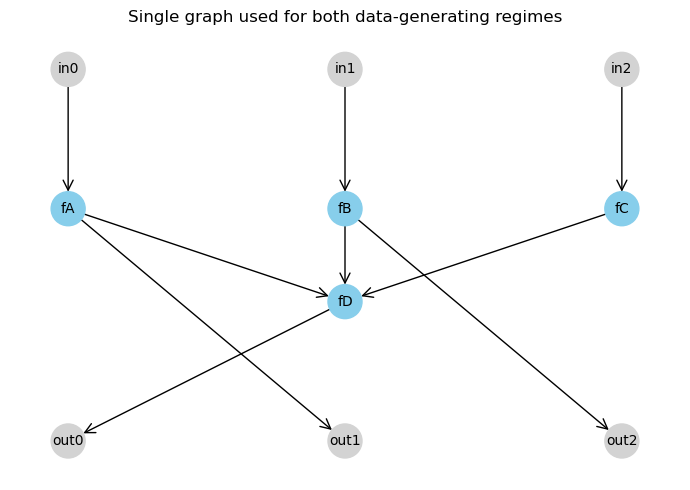

In [3]:
pos = {
    'in0': (-2, 2),  'in1': (0, 2),  'in2': (2, 2),
    'fA':  (-2, 0.5), 'fB': (0, 0.5), 'fC': (2, 0.5), 'fD': (0, -0.5),
    'out0': (-2, -2), 'out1': (0, -2), 'out2': (2, -2),
}

def color_for(n):
    if n in input_nodes:   return 'lightgray'
    if n in output_nodes:  return 'lightgray'
    return 'skyblue'

fig, ax = plt.subplots(figsize=(7, 5))
colors = [color_for(n) for n in G.nodes]
nx.draw_networkx(G, pos, ax=ax, node_color=colors, with_labels=True,
                 node_size=600, font_size=10, arrowstyle='->', arrowsize=18)
ax.set_title('Single graph used for both data-generating regimes')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Simulate two datasets from the same graph

Each regime uses a distinct set of `special_functions`. We also build a **one-hot condition vector** per sample and broadcast it to every function node as `x_fn` with shape `(B, Nf, 2)`.

In [4]:
special_functions_D1 = {
    'fA': lambda x: np.tanh(np.sum(x)),
    'fB': lambda x: -np.mean(x),
    'fC': lambda x: np.sum([xx**2 for xx in x]),
    'fD': lambda x: np.tanh(np.sum(x)),
}

special_functions_D2 = {
    'fA': lambda x: -np.tanh(np.sum(x)),
    'fB': lambda x: np.mean(x),
    'fC': lambda x: -np.sum([xx**2 for xx in x]),
    'fD': lambda x: -np.tanh(np.sum(x)),
}

N_TRAIN = 400
N_TEST  = 100

x_tr_1, x_te_1, y_tr_1, y_te_1 = simulate(G, n_train=N_TRAIN, n_test=N_TEST,
                                             input_nodes=input_nodes, output_nodes=output_nodes,
                                             special_functions=special_functions_D1, noise_scale=0.01)

x_tr_2, x_te_2, y_tr_2, y_te_2 = simulate(G, n_train=N_TRAIN, n_test=N_TEST,
                                             input_nodes=input_nodes, output_nodes=output_nodes,
                                             special_functions=special_functions_D2, noise_scale=0.01)

print('D1 shapes:', x_tr_1.shape, y_tr_1.shape)
print('D2 shapes:', x_tr_2.shape, y_tr_2.shape)

D1 shapes: (400, 3) (400, 3)
D2 shapes: (400, 3) (400, 3)


In [5]:
def condition_one_hot(n, source):
    oh = np.zeros((n, 2), dtype=np.float32)
    oh[:, source] = 1.0
    return oh

def broadcast_xfn(oh, n_fn):
    return np.broadcast_to(oh[:, None, :], (oh.shape[0], n_fn, oh.shape[1])).copy()

n_fn = len(function_nodes)

xfn_tr_1 = broadcast_xfn(condition_one_hot(N_TRAIN, 0), n_fn)
xfn_te_1 = broadcast_xfn(condition_one_hot(N_TEST,  0), n_fn)
xfn_tr_2 = broadcast_xfn(condition_one_hot(N_TRAIN, 1), n_fn)
xfn_te_2 = broadcast_xfn(condition_one_hot(N_TEST,  1), n_fn)

rng = np.random.default_rng(0)
perm = rng.permutation(2 * N_TRAIN)

def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

x_train   = to_tensor(np.concatenate([x_tr_1, x_tr_2], axis=0)[perm])
y_train   = to_tensor(np.concatenate([y_tr_1, y_tr_2], axis=0)[perm])
xfn_train = to_tensor(np.concatenate([xfn_tr_1, xfn_tr_2], axis=0)[perm])

x_test    = to_tensor(np.concatenate([x_te_1, x_te_2], axis=0))
y_test    = to_tensor(np.concatenate([y_te_1, y_te_2], axis=0))
xfn_test  = to_tensor(np.concatenate([xfn_te_1, xfn_te_2], axis=0))

test_source = np.array(['D1'] * N_TEST + ['D2'] * N_TEST)

print('Combined train:', x_train.shape, y_train.shape, xfn_train.shape)
print('Combined test :', x_test.shape,  y_test.shape,  xfn_test.shape)
print('x_fn example (first train row, node fA):', xfn_train[0, 0].cpu().numpy())

Combined train: torch.Size([800, 3]) torch.Size([800, 3]) torch.Size([800, 4, 2])
Combined test : torch.Size([200, 3]) torch.Size([200, 3]) torch.Size([200, 4, 2])
x_fn example (first train row, node fA): [0. 1.]


## Train three GSNNs on the combined dataset

- **Model A** sees only `x` and must average over both regimes.
- **Model B** uses per-node gating: one scalar gate per function node (identical across nodes when `x_fn` is broadcast).
- **Model C** uses per-channel gating: a vector of gates per function node from the same shared MLP.

Hyperparameters are otherwise identical.

In [6]:
data = nx2pyg(G, input_nodes, function_nodes, output_nodes)

gsnn_kwargs = dict(
    channels=5,
    layers=3,
    share_layers=False,
    bias=True,
    add_function_self_edges=False,
    checkpoint=False,
    norm='none',
    init='degree_normalized',
    residual=True,
    node_attn=False,
    node_mlp=False,
    dropout=0.,
)

def train(model, with_xfn, n_iters=1000, lr=1e-2, weight_decay=1e-2):
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit  = torch.nn.MSELoss()
    for i in range(n_iters):
        model.train(); optim.zero_grad()
        if with_xfn:
            yhat = model(x_train, x_fn=xfn_train)
        else:
            yhat = model(x_train)
        loss = crit(y_train, yhat)
        loss.backward()
        optim.step()
        if (i + 1) % 100 == 0 or i == n_iters - 1:
            model.eval()
            with torch.no_grad():
                if with_xfn:
                    yhat_te = model(x_test, x_fn=xfn_test)
                else:
                    yhat_te = model(x_test)
                te_loss = crit(y_test, yhat_te).item()
            print(f'  iter {i + 1:4d} | train mse: {loss.item():.4f} | test mse: {te_loss:.4f}', end='\r')
    print()
    return model

In [7]:
print('Training Model A (no node activity)...')
torch.manual_seed(0)
model_A = GSNN(data.edge_index_dict, data.node_names_dict,
               node_activity=False, **gsnn_kwargs).to(device)
train(model_A, with_xfn=False)

print('Training Model B (per-node node activity)...')
torch.manual_seed(0)
model_B = GSNN(data.edge_index_dict, data.node_names_dict,
               node_activity=True,
               node_activity_mode='per-node',
               node_activity_dim=2,
               node_activity_hidden=16,
               node_activity_temperature=0.5,
               **gsnn_kwargs).to(device)
train(model_B, with_xfn=True)

print('Training Model C (per-channel node activity)...')
torch.manual_seed(0)
model_C = GSNN(data.edge_index_dict, data.node_names_dict,
               node_activity=True,
               node_activity_mode='per-channel',
               node_activity_dim=2,
               node_activity_hidden=16,
               node_activity_temperature=0.5,
               **gsnn_kwargs).to(device)
train(model_C, with_xfn=True)

print('Model A params:', sum(p.numel() for p in model_A.parameters()))
print('Model B params:', sum(p.numel() for p in model_B.parameters()))
print('Model C params:', sum(p.numel() for p in model_C.parameters()))

Training Model A (no node activity)...
  iter 1000 | train mse: 0.4377 | test mse: 0.4625
Training Model B (per-node node activity)...
  iter 1000 | train mse: 0.2905 | test mse: 0.2792
Training Model C (per-channel node activity)...
  iter 1000 | train mse: 0.0026 | test mse: 0.0030
Model A params: 270
Model B params: 367
Model C params: 435


### Test performance

 Model A | test MSE: 0.4625
 Model B | test MSE: 0.2792
 Model C | test MSE: 0.0030


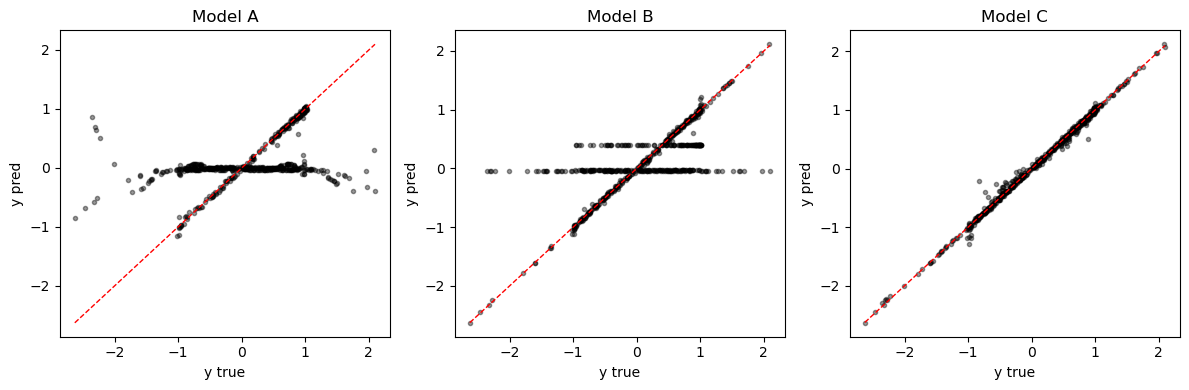

In [8]:
model_A.eval(); model_B.eval(); model_C.eval()
with torch.no_grad():
    yhat_A = model_A(x_test).cpu().numpy()
    yhat_B = model_B(x_test, x_fn=xfn_test).cpu().numpy()
    yhat_C = model_C(x_test, x_fn=xfn_test).cpu().numpy()
y_true = y_test.cpu().numpy()

def report(name, yhat):
    mse = float(np.mean((y_true - yhat) ** 2))
    print(f'{name:>8} | test MSE: {mse:.4f}')

report('Model A', yhat_A)
report('Model B', yhat_B)
report('Model C', yhat_C)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name, yhat in [(axes[0], 'Model A', yhat_A),
                       (axes[1], 'Model B', yhat_B),
                       (axes[2], 'Model C', yhat_C)]:
    ax.plot(y_true.ravel(), yhat.ravel(), 'k.', alpha=0.4)
    lo, hi = y_true.min(), y_true.max()
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(name); ax.set_xlabel('y true'); ax.set_ylabel('y pred')
plt.tight_layout()
plt.show()

## Predicted function-node activities

For **Model C** (per-channel), reshape the gate tensor to `(Nf, C_pn)` and plot heatmaps for one test sample from each regime. Under **Model B** (per-node), the same one-hot `x_fn` yields one scalar per node (constant across channels within each node).

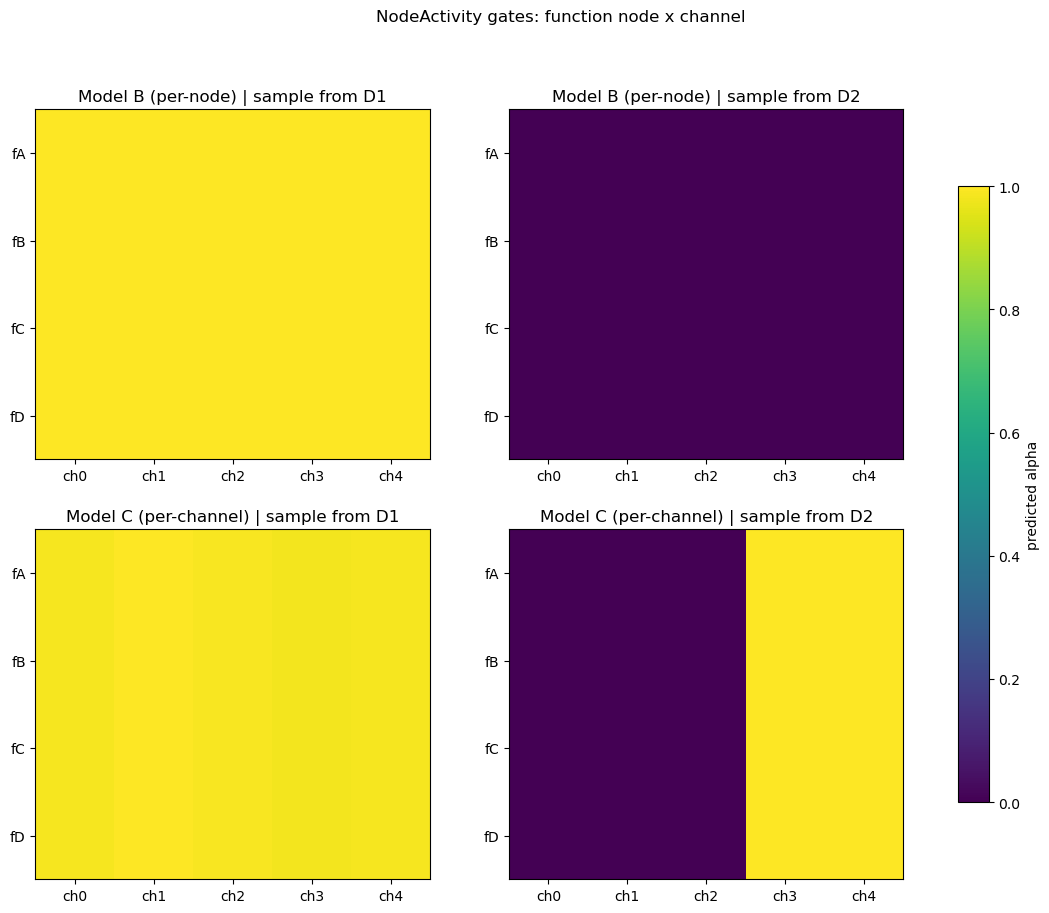

In [11]:
idx_d1 = 0
idx_d2 = N_TEST

obs_d1 = x_test[idx_d1:idx_d1 + 1]
obs_d2 = x_test[idx_d2:idx_d2 + 1]
xfn_d1 = xfn_test[idx_d1:idx_d1 + 1]
xfn_d2 = xfn_test[idx_d2:idx_d2 + 1]

def gate_matrix(model, xfn_obs):
    nact = model.node_activity_model
    nact.eval()
    with torch.no_grad():
        raw = nact(xfn_obs).view(1, nact.n_nodes, nact.channels_per_node)
    return raw[0].cpu().numpy()

alpha_C_d1 = gate_matrix(model_C, xfn_d1)
alpha_C_d2 = gate_matrix(model_C, xfn_d2)
alpha_B_d1 = gate_matrix(model_B, xfn_d1)
alpha_B_d2 = gate_matrix(model_B, xfn_d2)

nact = model_C.node_activity_model
assert nact.n_nodes == len(function_nodes), (
    f"NodeActivity expects {nact.n_nodes} function nodes, notebook uses {len(function_nodes)}"
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panels = [
    (axes[0, 0], alpha_B_d1, 'Model B (per-node) | sample from D1'),
    (axes[0, 1], alpha_B_d2, 'Model B (per-node) | sample from D2'),
    (axes[1, 0], alpha_C_d1, 'Model C (per-channel) | sample from D1'),
    (axes[1, 1], alpha_C_d2, 'Model C (per-channel) | sample from D2'),
]
for ax, alpha, title in panels:
    im = ax.imshow(alpha, aspect='auto', vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(np.arange(alpha.shape[1]))
    ax.set_xticklabels([f'ch{c}' for c in range(alpha.shape[1])])
    ax.set_yticks(np.arange(len(function_nodes)))
    ax.set_yticklabels(function_nodes)
    ax.set_title(title)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='predicted alpha')
fig.suptitle('NodeActivity gates: function node x channel')
plt.show()

## Takeaways

- **Predictive performance:** Model A must average over both data-generating regimes; Models B and C typically achieve lower test MSE because the one-hot `x_fn` tells the network which regime each sample came from.
- **Per-node vs. per-channel:** With the same one-hot `x_fn` broadcast to every function node, per-node mode can only apply one scalar gate per node (and the shared MLP produces the same scalar for every node given identical input). Per-channel mode learns a distinct gate for each latent channel, enabling richer condition-specific modulation with parameter sharing across nodes.
- **Extensions:** Replace the one-hot with real sample-level covariates (e.g. cell-line embeddings), increase `node_activity_dim`, or add more regimes — the same `per-channel` machinery applies.